# Linear Regression

This notebook reads the processed TTE table created by `exploration.ipynb`, evaluates the existing model with shuffled 10-fold cross-validation, and saves out-of-fold predictions and metrics.

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = PROJECT / "data" / "processed"
RESULTS = PROJECT / "results"
PLOTS = RESULTS / "plots"
RESULTS.mkdir(exist_ok=True)
PLOTS.mkdir(exist_ok=True)
N_SPLITS = 10
RANDOM_STATE = 42
FEATURES = ["month_sin", "month_cos", "sun_27", "sun_81", "sun_trend"] + [f"orbit_{c}" for c in ["G", "I", "C", "E", "P", "V"]] + ["prev_log_gap", "log_n_prev"]
df = pd.read_csv(PROCESSED / "tte.csv", parse_dates=["start"])
X, y = df[FEATURES], df.tte.to_numpy(float)
if len(df) < N_SPLITS or np.any(~np.isfinite(y)) or np.any(y <= 0):
    raise ValueError("Run exploration.ipynb first and ensure tte.csv contains enough valid rows.")
print(f"TTE observations: {len(df)}; satellites: {df.sat.nunique()}; folds: {N_SPLITS}")


TTE observations: 2437; satellites: 37; folds: 10


In [2]:
model = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("regressor", LinearRegression())])
oof_pred = np.full(len(df), np.nan)
fold = np.zeros(len(df), dtype=int)
kfold = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
for current_fold, (train_idx, test_idx) in enumerate(kfold.split(X), start=1):
    model.fit(X.iloc[train_idx], y[train_idx])
    oof_pred[test_idx] = model.predict(X.iloc[test_idx])
    fold[test_idx] = current_fold
rae = np.mean(np.abs(oof_pred - y) / y)
mae = mean_absolute_error(y, oof_pred)
rmse = mean_squared_error(y, oof_pred) ** 0.5
print(f"Linear Regression RAE: {rae:.6f} ({rae * 100:.2f}%)")
print(f"Linear Regression MAE: {mae:.3f} days")
print(f"Linear Regression RMSE: {rmse:.3f} days")


Linear Regression RAE: 4.757590 (475.76%)
Linear Regression MAE: 21.890 days
Linear Regression RMSE: 39.932 days


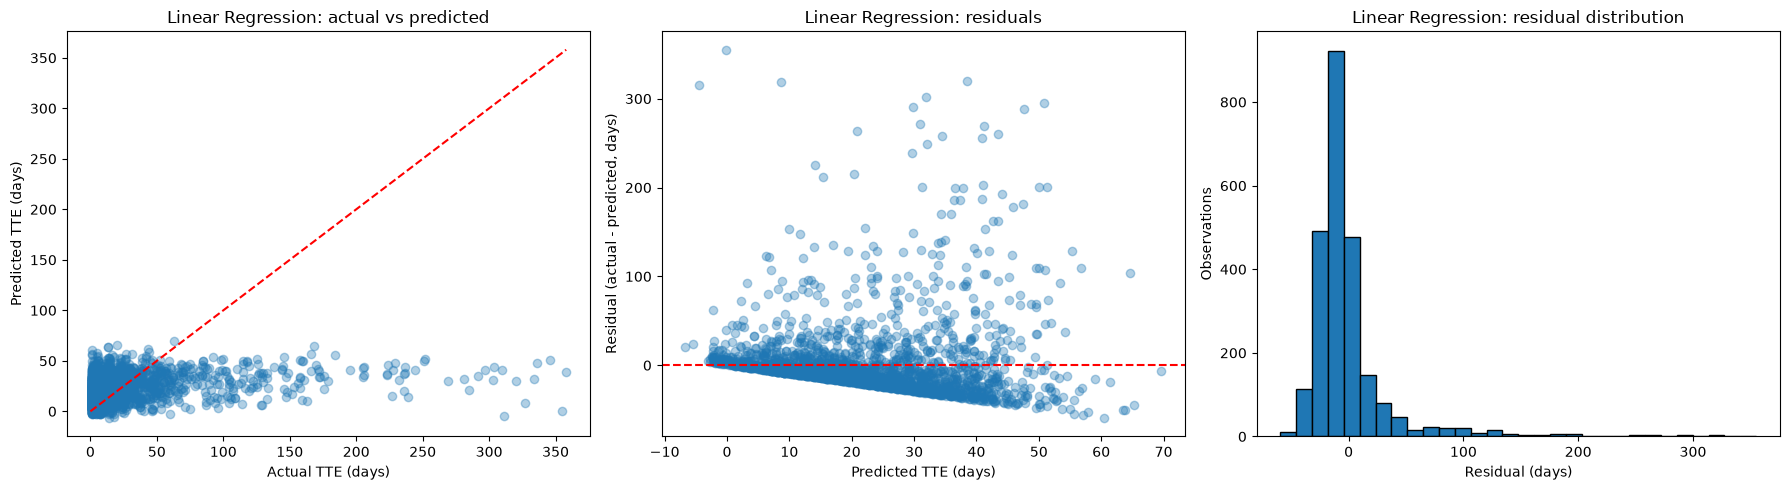

Saved predictions and metrics.


In [3]:
predictions = pd.DataFrame({"actual_tte": y, "predicted_tte": oof_pred, "fold": fold, "satellite": df.sat, "orbit": df.orbit, "start": df.start})
predictions.to_csv(RESULTS / "predictions_lr.csv", index=False)
metrics = {"model": "Linear Regression", "model_key": "lr", "status": "success", "n_observations": len(df), "n_satellites": df.sat.nunique(), "cv_folds": N_SPLITS, "rae": rae, "rae_percent": rae * 100, "mae_days": mae, "rmse_days": rmse, "configuration": json.dumps({"features": FEATURES, "cv": "shuffled KFold", "random_state": RANDOM_STATE})}
metrics_path = RESULTS / "metrics.csv"
existing = pd.read_csv(metrics_path) if metrics_path.exists() else pd.DataFrame()
if not existing.empty and "model_key" in existing.columns:
    existing = existing[existing.model_key != "lr"]
metrics_table = pd.concat([existing, pd.DataFrame([metrics])], ignore_index=True)
metrics_table.to_csv(metrics_path, index=False)
residuals = predictions.actual_tte - predictions.predicted_tte
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
limit = max(predictions.actual_tte.max(), predictions.predicted_tte.max())
axes[0].scatter(predictions.actual_tte, predictions.predicted_tte, alpha=.35); axes[0].plot([0, limit], [0, limit], "r--"); axes[0].set(xlabel="Actual TTE (days)", ylabel="Predicted TTE (days)", title="Linear Regression: actual vs predicted")
axes[1].scatter(predictions.predicted_tte, residuals, alpha=.35); axes[1].axhline(0, color="r", linestyle="--"); axes[1].set(xlabel="Predicted TTE (days)", ylabel="Residual (actual - predicted, days)", title="Linear Regression: residuals")
axes[2].hist(residuals, bins=30, edgecolor="black"); axes[2].set(xlabel="Residual (days)", ylabel="Observations", title="Linear Regression: residual distribution")
plt.tight_layout(); fig.savefig(PLOTS / "lr_evaluation.png", dpi=150); plt.show()
print("Saved predictions and metrics.")
